In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

PATH = "C:\Main_Drive\work\workarea\projects\credit_risk_prediction\data\home-credit-default-risk\application_train.csv"

In [2]:
features = [
"TARGET",

'CODE_GENDER',
'DAYS_BIRTH',
'NAME_FAMILY_STATUS',
'CNT_CHILDREN',
'CNT_FAM_MEMBERS',

'NAME_INCOME_TYPE',
'OCCUPATION_TYPE',
'ORGANIZATION_TYPE',
'DAYS_EMPLOYED',
'AMT_INCOME_TOTAL',

'NAME_CONTRACT_TYPE',
'AMT_CREDIT',
'AMT_ANNUITY',
'AMT_GOODS_PRICE',

'FLAG_OWN_CAR',
'FLAG_OWN_REALTY',
'NAME_HOUSING_TYPE'
] 

pd.set_option('display.max_columns', None)

In [3]:
home_credit_df = pd.read_csv(r"C:\Main_Drive\work\workarea\projects\credit_risk_prediction\data\home-credit-default-risk\application_train.csv",usecols=features) 

In [4]:
home_credit_df.head(20)

,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_INCOME_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,OCCUPATION_TYPE,CNT_FAM_MEMBERS,ORGANIZATION_TYPE
0,1,Cash loans,M,N,Y,0,202500.000,406597.5,24700.5,351000.0,Working,Single / not married,House / apartment,-9461,-637,Laborers,1.0,Business Entity Type 3
1,0,Cash loans,F,N,N,0,270000.000,1293502.5,35698.5,1129500.0,State servant,Married,House / apartment,-16765,-1188,Core staff,2.0,School
2,0,Revolving loans,M,Y,Y,0,67500.000,135000.0,6750.0,135000.0,Working,Single / not married,House / apartment,-19046,-225,Laborers,1.0,Government
3,0,Cash loans,F,N,Y,0,135000.000,312682.5,29686.5,297000.0,Working,Civil marriage,House / apartment,-19005,-3039,Laborers,2.0,Business Entity Type 3
4,0,Cash loans,M,N,Y,0,121500.000,513000.0,21865.5,513000.0,Working,Single / not married,House / apartment,-19932,-3038,Core staff,1.0,Religion
5,0,Cash loans,M,N,Y,0,99000.000,490495.5,27517.5,454500.0,State servant,Married,House / apartment,-16941,-1588,Laborers,2.0,Other
6,0,Cash loans,F,Y,Y,1,171000.000,1560726.0,41301.0,1395000.0,Commercial associate,Married,House / apartment,-13778,-3130,Accountants,3.0,Business Entity Type 3
7,0,Cash loans,M,Y,Y,0,360000.000,1530000.0,42075.0,1530000.0,State servant,Married,House / apartment,-18850,-449,Managers,2.0,Other
8,0,Cash loans,F,N,Y,0,112500.000,1019610.0,33826.5,913500.0,Pensioner,Married,House / apartment,-20099,365243,NaN,2.0,XNA
9,0,Revolving loans,M,N,Y,0,135000.000,405000.0,20250.0,405000.0,Working,Single / not married,House / apartment,-14469,-2019,Laborers,1.0,Electricity


In [5]:
home_credit_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 18 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   TARGET              307511 non-null  int64  
 1   NAME_CONTRACT_TYPE  307511 non-null  object 
 2   CODE_GENDER         307511 non-null  object 
 3   FLAG_OWN_CAR        307511 non-null  object 
 4   FLAG_OWN_REALTY     307511 non-null  object 
 5   CNT_CHILDREN        307511 non-null  int64  
 6   AMT_INCOME_TOTAL    307511 non-null  float64
 7   AMT_CREDIT          307511 non-null  float64
 8   AMT_ANNUITY         307499 non-null  float64
 9   AMT_GOODS_PRICE     307233 non-null  float64
 10  NAME_INCOME_TYPE    307511 non-null  object 
 11  NAME_FAMILY_STATUS  307511 non-null  object 
 12  NAME_HOUSING_TYPE   307511 non-null  object 
 13  DAYS_BIRTH          307511 non-null  int64  
 14  DAYS_EMPLOYED       307511 non-null  int64  
 15  OCCUPATION_TYPE     211120 non-nul

In [6]:
home_credit_df.nunique()

TARGET                    2
NAME_CONTRACT_TYPE        2
CODE_GENDER               3
FLAG_OWN_CAR              2
FLAG_OWN_REALTY           2
CNT_CHILDREN             15
AMT_INCOME_TOTAL       2548
AMT_CREDIT             5603
AMT_ANNUITY           13672
AMT_GOODS_PRICE        1002
NAME_INCOME_TYPE          8
NAME_FAMILY_STATUS        6
NAME_HOUSING_TYPE         6
DAYS_BIRTH            17460
DAYS_EMPLOYED         12574
OCCUPATION_TYPE          18
CNT_FAM_MEMBERS          17
ORGANIZATION_TYPE        58
dtype: int64

In [7]:
home_credit_df.dtypes

TARGET                  int64
NAME_CONTRACT_TYPE     object
CODE_GENDER            object
FLAG_OWN_CAR           object
FLAG_OWN_REALTY        object
CNT_CHILDREN            int64
AMT_INCOME_TOTAL      float64
AMT_CREDIT            float64
AMT_ANNUITY           float64
AMT_GOODS_PRICE       float64
NAME_INCOME_TYPE       object
NAME_FAMILY_STATUS     object
NAME_HOUSING_TYPE      object
DAYS_BIRTH              int64
DAYS_EMPLOYED           int64
OCCUPATION_TYPE        object
CNT_FAM_MEMBERS       float64
ORGANIZATION_TYPE      object
dtype: object

In [8]:
categorical_features = home_credit_df.select_dtypes(include = object).columns.tolist()
categorical_features

['NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'NAME_INCOME_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'OCCUPATION_TYPE',
 'ORGANIZATION_TYPE']

In [9]:
numerical_features = home_credit_df.select_dtypes(exclude = object).drop(columns = ["TARGET"]).columns.tolist() 
numerical_features

['CNT_CHILDREN',
 'AMT_INCOME_TOTAL',
 'AMT_CREDIT',
 'AMT_ANNUITY',
 'AMT_GOODS_PRICE',
 'DAYS_BIRTH',
 'DAYS_EMPLOYED',
 'CNT_FAM_MEMBERS']

In [10]:
corre = home_credit_df[numerical_features+["TARGET"]].corr()

In [11]:
corre["TARGET"].sort_values(ascending = False)

TARGET              1.000000
DAYS_BIRTH          0.078239
CNT_CHILDREN        0.019187
CNT_FAM_MEMBERS     0.009308
AMT_INCOME_TOTAL   -0.003982
AMT_ANNUITY        -0.012817
AMT_CREDIT         -0.030369
AMT_GOODS_PRICE    -0.039645
DAYS_EMPLOYED      -0.044932
Name: TARGET, dtype: float64

In [12]:
home_credit_df[numerical_features].isnull().sum()

CNT_CHILDREN          0
AMT_INCOME_TOTAL      0
AMT_CREDIT            0
AMT_ANNUITY          12
AMT_GOODS_PRICE     278
DAYS_BIRTH            0
DAYS_EMPLOYED         0
CNT_FAM_MEMBERS       2
dtype: int64

In [13]:
home_credit_df[categorical_features].nunique()

NAME_CONTRACT_TYPE     2
CODE_GENDER            3
FLAG_OWN_CAR           2
FLAG_OWN_REALTY        2
NAME_INCOME_TYPE       8
NAME_FAMILY_STATUS     6
NAME_HOUSING_TYPE      6
OCCUPATION_TYPE       18
ORGANIZATION_TYPE     58
dtype: int64

In [14]:
home_credit_df["ORGANIZATION_TYPE"].value_counts()

ORGANIZATION_TYPE
Business Entity Type 3    67992
XNA                       55374
Self-employed             38412
Other                     16683
Medicine                  11193
Business Entity Type 2    10553
Government                10404
School                     8893
Trade: type 7              7831
Kindergarten               6880
Construction               6721
Business Entity Type 1     5984
Transport: type 4          5398
Trade: type 3              3492
Industry: type 9           3368
Industry: type 3           3278
Security                   3247
Housing                    2958
Industry: type 11          2704
Military                   2634
Bank                       2507
Agriculture                2454
Police                     2341
Transport: type 2          2204
Postal                     2157
Security Ministries        1974
Trade: type 2              1900
Restaurant                 1811
Services                   1575
University                 1327
Industry: type 7      

In [15]:
home_credit_df["OCCUPATION_TYPE"].value_counts()

OCCUPATION_TYPE
Laborers                 55186
Sales staff              32102
Core staff               27570
Managers                 21371
Drivers                  18603
High skill tech staff    11380
Accountants               9813
Medicine staff            8537
Security staff            6721
Cooking staff             5946
Cleaning staff            4653
Private service staff     2652
Low-skill Laborers        2093
Waiters/barmen staff      1348
Secretaries               1305
Realty agents              751
HR staff                   563
IT staff                   526
Name: count, dtype: int64

In [16]:
# NAME_INCOME_TYPE       8
# NAME_FAMILY_STATUS     6
# NAME_HOUSING_TYPE      6

home_credit_df["NAME_INCOME_TYPE"].value_counts()

NAME_INCOME_TYPE
Working                 158774
Commercial associate     71617
Pensioner                55362
State servant            21703
Unemployed                  22
Student                     18
Businessman                 10
Maternity leave              5
Name: count, dtype: int64

In [17]:
# NAME_INCOME_TYPE       8
# NAME_FAMILY_STATUS     6
# NAME_HOUSING_TYPE      6

home_credit_df["NAME_FAMILY_STATUS"].value_counts()

NAME_FAMILY_STATUS
Married                 196432
Single / not married     45444
Civil marriage           29775
Separated                19770
Widow                    16088
Unknown                      2
Name: count, dtype: int64

In [18]:
home_credit_df["NAME_HOUSING_TYPE"].value_counts()

NAME_HOUSING_TYPE
House / apartment      272868
With parents            14840
Municipal apartment     11183
Rented apartment         4881
Office apartment         2617
Co-op apartment          1122
Name: count, dtype: int64

In [19]:
def group_organization(x):

    government = [
        "Government",
        "Police",
        "Military",
        "Security Ministries",
        "Postal",
        "School",
        "University",
        "Emergency"
    ]

    healthcare = [
        "Medicine"
    ]

    business = [
        "Business Entity Type 1",
        "Business Entity Type 2",
        "Business Entity Type 3",
        "Self-employed",
        "Realtor",
        "Advertising",
        "Insurance",
        "Legal Services"
    ]

    trade_services = [
        "Trade: type 1",
        "Trade: type 2",
        "Trade: type 3",
        "Trade: type 4",
        "Trade: type 5",
        "Trade: type 6",
        "Trade: type 7",
        "Restaurant",
        "Hotel",
        "Services",
        "Cleaning"
    ]

    industrial = [
        "Construction",
        "Electricity",
        "Agriculture",
        "Industry: type 1",
        "Industry: type 2",
        "Industry: type 3",
        "Industry: type 4",
        "Industry: type 5",
        "Industry: type 6",
        "Industry: type 7",
        "Industry: type 8",
        "Industry: type 9",
        "Industry: type 10",
        "Industry: type 11",
        "Industry: type 12",
        "Industry: type 13"
    ]

    transport = [
        "Transport: type 1",
        "Transport: type 2",
        "Transport: type 3",
        "Transport: type 4"
    ]

    telecom_finance = [
        "Telecom",
        "Bank",
        "Mobile"
    ]

    if x in government:
        return "Government"

    elif x in healthcare:
        return "Healthcare"

    elif x in business:
        return "Business"

    elif x in trade_services:
        return "Trade_Service"

    elif x in industrial:
        return "Industrial"

    elif x in transport:
        return "Transport"

    elif x in telecom_finance:
        return "Finance_Telecom"

    elif x == "XNA":
        return "Unknown"

    else:
        return "Other"

In [20]:
home_credit_df_2 = home_credit_df.copy()
home_credit_df_2

,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_INCOME_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,OCCUPATION_TYPE,CNT_FAM_MEMBERS,ORGANIZATION_TYPE
0,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Working,Single / not married,House / apartment,-9461,-637,Laborers,1.0,Business Entity Type 3
1,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,State servant,Married,House / apartment,-16765,-1188,Core staff,2.0,School
2,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Working,Single / not married,House / apartment,-19046,-225,Laborers,1.0,Government
3,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,Working,Civil marriage,House / apartment,-19005,-3039,Laborers,2.0,Business Entity Type 3
4,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,Working,Single / not married,House / apartment,-19932,-3038,Core staff,1.0,Religion
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,225000.0,Working,Separated,With parents,-9327,-236,Sales staff,1.0,Services
307507,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,225000.0,Pensioner,Widow,House / apartment,-20775,365243,NaN,1.0,XNA
307508,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,585000.0,Working,Separated,House / apartment,-14966,-7921,Managers,1.0,School
307509,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,319500.0,Commercial associate,Married,House / apartment,-11961,-4786,Laborers,2.0,Business Entity Type 1


In [21]:
# grouping

home_credit_df_2["ORGANIZATION_TYPE_1"] = home_credit_df_2["ORGANIZATION_TYPE"].apply(group_organization)
home_credit_df_2 = home_credit_df_2.drop(columns = ["ORGANIZATION_TYPE"])

In [22]:
home_credit_df_2

,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_INCOME_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,OCCUPATION_TYPE,CNT_FAM_MEMBERS,ORGANIZATION_TYPE_1
0,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Working,Single / not married,House / apartment,-9461,-637,Laborers,1.0,Business
1,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,State servant,Married,House / apartment,-16765,-1188,Core staff,2.0,Government
2,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Working,Single / not married,House / apartment,-19046,-225,Laborers,1.0,Government
3,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,Working,Civil marriage,House / apartment,-19005,-3039,Laborers,2.0,Business
4,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,Working,Single / not married,House / apartment,-19932,-3038,Core staff,1.0,Other
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,225000.0,Working,Separated,With parents,-9327,-236,Sales staff,1.0,Trade_Service
307507,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,225000.0,Pensioner,Widow,House / apartment,-20775,365243,NaN,1.0,Unknown
307508,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,585000.0,Working,Separated,House / apartment,-14966,-7921,Managers,1.0,Government
307509,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,319500.0,Commercial associate,Married,House / apartment,-11961,-4786,Laborers,2.0,Business


In [23]:
home_credit_df_2['ORGANIZATION_TYPE_1'].nunique()

9

In [24]:
# grouping


def group_occupation(x):
    other = ["Unemployed","Student","Businessman","Maternity leave"]
    if x in other:
        return "other"
    else:
        return x

home_credit_df_2["NAME_INCOME_TYPE_1"] = home_credit_df_2["NAME_INCOME_TYPE"].apply(group_occupation)
home_credit_df_2 = home_credit_df_2.drop(columns = ["NAME_INCOME_TYPE"])


In [25]:
home_credit_df_2

,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,OCCUPATION_TYPE,CNT_FAM_MEMBERS,ORGANIZATION_TYPE_1,NAME_INCOME_TYPE_1
0,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Single / not married,House / apartment,-9461,-637,Laborers,1.0,Business,Working
1,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Married,House / apartment,-16765,-1188,Core staff,2.0,Government,State servant
2,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Single / not married,House / apartment,-19046,-225,Laborers,1.0,Government,Working
3,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,Civil marriage,House / apartment,-19005,-3039,Laborers,2.0,Business,Working
4,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,Single / not married,House / apartment,-19932,-3038,Core staff,1.0,Other,Working
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,225000.0,Separated,With parents,-9327,-236,Sales staff,1.0,Trade_Service,Working
307507,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,225000.0,Widow,House / apartment,-20775,365243,NaN,1.0,Unknown,Pensioner
307508,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,585000.0,Separated,House / apartment,-14966,-7921,Managers,1.0,Government,Working
307509,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,319500.0,Married,House / apartment,-11961,-4786,Laborers,2.0,Business,Commercial associate


In [26]:
home_credit_df_2["CODE_GENDER"].value_counts()


CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64

In [27]:
home_credit_df_2["CODE_GENDER"] = home_credit_df_2["CODE_GENDER"].replace("XNA","F")
home_credit_df_2["CODE_GENDER"].value_counts()


CODE_GENDER
F    202452
M    105059
Name: count, dtype: int64

In [28]:
categorical_features2 = home_credit_df_2.select_dtypes(include = object).columns.tolist()
categorical_features2

['NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'OCCUPATION_TYPE',
 'ORGANIZATION_TYPE_1',
 'NAME_INCOME_TYPE_1']

In [29]:
home_credit_df_2[categorical_features2].nunique()

NAME_CONTRACT_TYPE      2
CODE_GENDER             2
FLAG_OWN_CAR            2
FLAG_OWN_REALTY         2
NAME_FAMILY_STATUS      6
NAME_HOUSING_TYPE       6
OCCUPATION_TYPE        18
ORGANIZATION_TYPE_1     9
NAME_INCOME_TYPE_1      5
dtype: int64

In [30]:
numerical_features2 = home_credit_df_2.select_dtypes(exclude = object).drop(columns = ["TARGET"]).columns.tolist() 
numerical_features2

['CNT_CHILDREN',
 'AMT_INCOME_TOTAL',
 'AMT_CREDIT',
 'AMT_ANNUITY',
 'AMT_GOODS_PRICE',
 'DAYS_BIRTH',
 'DAYS_EMPLOYED',
 'CNT_FAM_MEMBERS']

In [31]:
home_credit_df_2["DAYS_BIRTH"]=(home_credit_df_2["DAYS_BIRTH"].abs())
home_credit_df_2["DAYS_EMPLOYED"]=(home_credit_df_2["DAYS_EMPLOYED"].abs())
home_credit_df_2

,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,OCCUPATION_TYPE,CNT_FAM_MEMBERS,ORGANIZATION_TYPE_1,NAME_INCOME_TYPE_1
0,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Single / not married,House / apartment,9461,637,Laborers,1.0,Business,Working
1,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Married,House / apartment,16765,1188,Core staff,2.0,Government,State servant
2,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Single / not married,House / apartment,19046,225,Laborers,1.0,Government,Working
3,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,Civil marriage,House / apartment,19005,3039,Laborers,2.0,Business,Working
4,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,Single / not married,House / apartment,19932,3038,Core staff,1.0,Other,Working
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,225000.0,Separated,With parents,9327,236,Sales staff,1.0,Trade_Service,Working
307507,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,225000.0,Widow,House / apartment,20775,365243,NaN,1.0,Unknown,Pensioner
307508,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,585000.0,Separated,House / apartment,14966,7921,Managers,1.0,Government,Working
307509,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,319500.0,Married,House / apartment,11961,4786,Laborers,2.0,Business,Commercial associate


In [32]:
home_credit_df_2[numerical_features2].isnull().sum()

CNT_CHILDREN          0
AMT_INCOME_TOTAL      0
AMT_CREDIT            0
AMT_ANNUITY          12
AMT_GOODS_PRICE     278
DAYS_BIRTH            0
DAYS_EMPLOYED         0
CNT_FAM_MEMBERS       2
dtype: int64

In [33]:
# feature engineering 

from sklearn.base import (BaseEstimator, TransformerMixin)

def group_organization(x):

    government = [
        "Government",
        "Police",
        "Military",
        "Security Ministries",
        "Postal",
        "School",
        "University",
        "Emergency",
        "Kindergarten",
        "Housing",
        "Security"
    ]

    healthcare = [
        "Medicine"
    ]

    business = [
        "Business Entity Type 1",
        "Business Entity Type 2",
        "Business Entity Type 3",
        "Self-employed",
        "Realtor",
        "Advertising",
        "Insurance",
        "Legal Services"
    ]

    trade_services = [
        "Trade: type 1",
        "Trade: type 2",
        "Trade: type 3",
        "Trade: type 4",
        "Trade: type 5",
        "Trade: type 6",
        "Trade: type 7",
        "Restaurant",
        "Hotel",
        "Services",
        "Cleaning"
    ]

    industrial = [
        "Construction",
        "Electricity",
        "Agriculture",
        "Industry: type 1",
        "Industry: type 2",
        "Industry: type 3",
        "Industry: type 4",
        "Industry: type 5",
        "Industry: type 6",
        "Industry: type 7",
        "Industry: type 8",
        "Industry: type 9",
        "Industry: type 10",
        "Industry: type 11",
        "Industry: type 12",
        "Industry: type 13"
    ]

    transport = [
        "Transport: type 1",
        "Transport: type 2",
        "Transport: type 3",
        "Transport: type 4"
    ]

    finance_telecom = [
        "Telecom",
        "Bank",
        "Mobile"
    ]

    if x in government:
        return "Government"

    elif x in healthcare:
        return "Healthcare"

    elif x in business:
        return "Business"

    elif x in trade_services:
        return "Trade_Service"

    elif x in industrial:
        return "Industrial"

    elif x in transport:
        return "Transport"

    elif x in finance_telecom:
        return "Finance_Telecom"

    elif x == "XNA":
        return "Unknown"

    else:
        return "Other"


def group_income_type(x):

    other = [
        "Unemployed",
        "Student",
        "Businessman",
        "Maternity leave"
    ]

    if x in other:
        return "Other"

    return x

In [41]:
class FeatureEngineering(
    BaseEstimator,
    TransformerMixin
):

    def fit(self, X, y=None):
        return self


    def transform(self, X):

        X = X.copy()

        # -------------------
        # Fix anomalies
        # -------------------

        X["DAYS_EMPLOYED"] = (
            X["DAYS_EMPLOYED"]
            .replace(365243, np.nan)
        )

        X["CODE_GENDER"] = (
            X["CODE_GENDER"]
            .replace("XNA", "F")
        )

        # -------------------
        # Feature Engineering
        # -------------------

        # Age in years
        X["AGE"] = (
            X["DAYS_BIRTH"].abs() / 365
        )

        # Employment years
        X["EMPLOYMENT_YEARS"] = (
            X["DAYS_EMPLOYED"].abs() / 365
        )

        # Loan burden
        X["CREDIT_INCOME_RATIO"] = (
            X["AMT_CREDIT"] /
            X["AMT_INCOME_TOTAL"]
        )

        # Family financial burden
        X["INCOME_PER_MEMBER"] = (
            X["AMT_INCOME_TOTAL"] /
            X["CNT_FAM_MEMBERS"]
        )

        # -------------------
        # Group categories
        # -------------------

        X["ORGANIZATION_TYPE"] = (
            X["ORGANIZATION_TYPE"]
            .apply(group_organization)
        )

        X["NAME_INCOME_TYPE"] = (
            X["NAME_INCOME_TYPE"]
            .apply(group_income_type)
        )
        
        X["EMI_INCOME_RATIO"] = (X["AMT_ANNUITY"] /X["AMT_INCOME_TOTAL"])

        # -------------------
        # Drop raw columns
        # -------------------

        X.drop(
            columns=[
                "DAYS_BIRTH",
                "DAYS_EMPLOYED"
            ],
            inplace=True
        )

        return X

In [42]:
numerical_features = [

    "CNT_CHILDREN",

    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",

    "CNT_FAM_MEMBERS",

    # engineered features
    "AGE",
    "EMPLOYMENT_YEARS",
    "CREDIT_INCOME_RATIO",
    "INCOME_PER_MEMBER"
]


categorical_features = [

    "NAME_CONTRACT_TYPE",

    "CODE_GENDER",

    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY",

    "NAME_INCOME_TYPE",

    "NAME_FAMILY_STATUS",

    "NAME_HOUSING_TYPE",

    "OCCUPATION_TYPE",

    "ORGANIZATION_TYPE"
]

In [43]:
from sklearn.pipeline import Pipeline

from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import OneHotEncoder,StandardScaler

from sklearn.impute import SimpleImputer

In [44]:
numeric_transformer = Pipeline([("imputer",SimpleImputer(strategy="median" )),("scaler",StandardScaler())])

categorical_transformer = Pipeline([("imputer",SimpleImputer(strategy="most_frequent")),("encoder",OneHotEncoder(handle_unknown="ignore"))])

In [45]:
preprocessor = ColumnTransformer([("num",numeric_transformer,numerical_features),("cat",categorical_transformer,categorical_features)])

In [46]:
from sklearn.linear_model import LogisticRegression

In [56]:
pipeline = Pipeline([("feature_engineering",FeatureEngineering()),("preprocessing",preprocessor),
                     ("model",LogisticRegression(class_weight="balanced",max_iter=1000,random_state=42))])

In [57]:
home_credit_df_3 = home_credit_df.copy()

In [58]:
from sklearn.model_selection import (train_test_split)

In [ ]:
X = home_credit_df_3.drop(
    "TARGET",
    axis=1
)

y = home_credit_df_3["TARGET"]


X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.2,
        stratify=y,
        random_state=42
    )
)

In [65]:
pipeline.fit(
    X_train,
    y_train
)


,steps,"[('feature_engineering', ...), ('preprocessing', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [66]:
y_pred = pipeline.predict(
    X_test
)

In [67]:
y_prob = (
    pipeline.predict_proba(
        X_test
    )[:,1]
    
)

In [68]:
from sklearn.metrics import (
    classification_report
)

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.95      0.61      0.74     56538
           1       0.12      0.62      0.20      4965

    accuracy                           0.61     61503
   macro avg       0.53      0.61      0.47     61503
weighted avg       0.88      0.61      0.70     61503



In [69]:
risk_prob = (
    pipeline.predict_proba(X_test)
)


In [70]:
risk_score = (
    pipeline.predict_proba(X_test)
    [:,1]
)
print(risk_score[:10])

[0.60134501 0.40313245 0.64763168 0.58087305 0.52212082 0.58104769
 0.17630076 0.2557385  0.57190509 0.30601224]


In [71]:
home_credit_df_3[10:20]

,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_INCOME_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,OCCUPATION_TYPE,CNT_FAM_MEMBERS,ORGANIZATION_TYPE
10,0,Cash loans,F,N,Y,1,112500.000,652500.0,21177.0,652500.0,Working,Married,House / apartment,-10197,-679,Core staff,3.0,Medicine
11,0,Cash loans,F,N,Y,0,38419.155,148365.0,10678.5,135000.0,Pensioner,Married,House / apartment,-20417,365243,NaN,2.0,XNA
12,0,Cash loans,F,N,Y,0,67500.000,80865.0,5881.5,67500.0,Working,Married,House / apartment,-13439,-2717,Laborers,2.0,Business Entity Type 2
13,0,Cash loans,M,Y,N,1,225000.000,918468.0,28966.5,697500.0,Working,Married,House / apartment,-14086,-3028,Drivers,3.0,Self-employed
14,0,Cash loans,F,N,Y,0,189000.000,773680.5,32778.0,679500.0,Working,Married,House / apartment,-14583,-203,Laborers,2.0,Transport: type 2
15,0,Cash loans,M,Y,Y,0,157500.000,299772.0,20160.0,247500.0,Working,Single / not married,Rented apartment,-8728,-1157,Laborers,1.0,Business Entity Type 2
16,0,Cash loans,M,N,N,0,108000.000,509602.5,26149.5,387000.0,Working,Married,House / apartment,-12931,-1317,Drivers,2.0,Government
17,0,Revolving loans,F,N,Y,1,81000.000,270000.0,13500.0,270000.0,Working,Married,House / apartment,-9776,-191,Laborers,3.0,Construction
18,0,Revolving loans,F,N,Y,0,112500.000,157500.0,7875.0,157500.0,Working,Widow,House / apartment,-17718,-7804,Laborers,1.0,Housing
19,0,Cash loans,F,N,Y,1,90000.000,544491.0,17563.5,454500.0,State servant,Single / not married,House / apartment,-11348,-2038,Core staff,2.0,Kindergarten


# rf

In [72]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Random Forest Pipeline
pipeline_rf = Pipeline([
    ("feature_engineering", FeatureEngineering()),
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        max_depth=12,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

# Train
pipeline_rf.fit(X_train, y_train)

# Prediction
y_pred_rf = pipeline_rf.predict(X_test)

# Risk Probability (Default Probability)
y_prob_rf = pipeline_rf.predict_proba(X_test)[:,1]

# Risk Score %
risk_score_rf = y_prob_rf * 100

# Evaluation
print("="*60)
print("RANDOM FOREST RESULTS")
print("="*60)

print(classification_report(y_test, y_pred_rf))

print("ROC-AUC Score:",
      round(roc_auc_score(y_test, y_prob_rf), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nSample Risk Scores:")
print(risk_score_rf[:10])

RANDOM FOREST RESULTS
              precision    recall  f1-score   support

           0       0.94      0.72      0.81     56538
           1       0.14      0.52      0.22      4965

    accuracy                           0.70     61503
   macro avg       0.54      0.62      0.52     61503
weighted avg       0.88      0.70      0.77     61503

ROC-AUC Score: 0.6604

Confusion Matrix:
[[40491 16047]
 [ 2403  2562]]

Sample Risk Scores:
[52.32204392 44.02491371 57.82849925 46.81250373 51.48778309 55.4464967
 23.54117687 28.76362677 49.34047253 30.77084718]


In [73]:
home_credit_df_3[:10]

,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_INCOME_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,OCCUPATION_TYPE,CNT_FAM_MEMBERS,ORGANIZATION_TYPE
0,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Working,Single / not married,House / apartment,-9461,-637,Laborers,1.0,Business Entity Type 3
1,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,State servant,Married,House / apartment,-16765,-1188,Core staff,2.0,School
2,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Working,Single / not married,House / apartment,-19046,-225,Laborers,1.0,Government
3,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,Working,Civil marriage,House / apartment,-19005,-3039,Laborers,2.0,Business Entity Type 3
4,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,Working,Single / not married,House / apartment,-19932,-3038,Core staff,1.0,Religion
5,0,Cash loans,M,N,Y,0,99000.0,490495.5,27517.5,454500.0,State servant,Married,House / apartment,-16941,-1588,Laborers,2.0,Other
6,0,Cash loans,F,Y,Y,1,171000.0,1560726.0,41301.0,1395000.0,Commercial associate,Married,House / apartment,-13778,-3130,Accountants,3.0,Business Entity Type 3
7,0,Cash loans,M,Y,Y,0,360000.0,1530000.0,42075.0,1530000.0,State servant,Married,House / apartment,-18850,-449,Managers,2.0,Other
8,0,Cash loans,F,N,Y,0,112500.0,1019610.0,33826.5,913500.0,Pensioner,Married,House / apartment,-20099,365243,NaN,2.0,XNA
9,0,Revolving loans,M,N,Y,0,135000.0,405000.0,20250.0,405000.0,Working,Single / not married,House / apartment,-14469,-2019,Laborers,1.0,Electricity


In [74]:
risk_score = (
    pipeline.predict_proba(X_test)
    [:,1]
)
print(risk_score[:10])


[0.60134501 0.40313245 0.64763168 0.58087305 0.52212082 0.58104769
 0.17630076 0.2557385  0.57190509 0.30601224]


In [75]:
import joblib 
joblib.dump(pipeline_rf,"model_rf.pkl")

['model_rf.pkl']

In [76]:
joblib.dump(FeatureEngineering,"FeatureEngineering. pkl") 

['FeatureEngineering. pkl']

In [77]:
import importlib
import feature_engineering

importlib.reload(feature_engineering)

<module 'feature_engineering' from 'C:\\Main_Drive\\work\\workarea\\projects\\credit_risk_prediction\\notebook\\feature_engineering.py'>

In [78]:
from feature_engineering import FeatureEngineering


from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Random Forest Pipeline
pipeline_rf = Pipeline([
    ("feature_engineering", FeatureEngineering()),
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        max_depth=12,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

# Train
pipeline_rf.fit(X_train, y_train)

# Prediction
y_pred_rf = pipeline_rf.predict(X_test)

# Risk Probability (Default Probability)
y_prob_rf = pipeline_rf.predict_proba(X_test)[:,1]

# Risk Score %
risk_score_rf = y_prob_rf * 100

# Evaluation
print("="*60)
print("RANDOM FOREST RESULTS")
print("="*60)

print(classification_report(y_test, y_pred_rf))

print("ROC-AUC Score:",
      round(roc_auc_score(y_test, y_prob_rf), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nSample Risk Scores:")
print(risk_score_rf[:10])

RANDOM FOREST RESULTS
              precision    recall  f1-score   support

           0       0.94      0.72      0.81     56538
           1       0.14      0.52      0.22      4965

    accuracy                           0.70     61503
   macro avg       0.54      0.62      0.52     61503
weighted avg       0.88      0.70      0.77     61503

ROC-AUC Score: 0.6604

Confusion Matrix:
[[40491 16047]
 [ 2403  2562]]

Sample Risk Scores:
[52.32204392 44.02491371 57.82849925 46.81250373 51.48778309 55.4464967
 23.54117687 28.76362677 49.34047253 30.77084718]


In [79]:
import joblib 
joblib.dump(pipeline_rf,"model_rf.pkl")

['model_rf.pkl']

# final

In [ ]:
pipeline_rf

In [80]:

model_rf_v2 = RandomForestClassifier(n_estimators=200,max_depth=15,min_samples_leaf=3,class_weight={0:1,1:4},random_state=42,n_jobs=-1)

pipeline_rf_v2 = Pipeline([
        (
            "feature_engineering",
            FeatureEngineering()
        ),
        (
            "preprocessing",
            preprocessor
        ),
        (
            "model",
            model_rf_v2
        )
    ])

pipeline_rf_v2.fit(
        X_train,
        y_train
    )

,steps,"[('feature_engineering', ...), ('preprocessing', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [142]:
random_1 = {
  "NAME_CONTRACT_TYPE": "Cash loans",
  "CODE_GENDER": "M",
  "FLAG_OWN_CAR": "N",
  "FLAG_OWN_REALTY": "N",
  "CNT_CHILDREN": 0,
  "AMT_INCOME_TOTAL": 300000.0,
  "AMT_CREDIT": 500000.0,
  "AMT_ANNUITY": 4339.0,
  "AMT_GOODS_PRICE": 600000.0,
  "NAME_INCOME_TYPE": "Working",
  "NAME_FAMILY_STATUS": "Married",
  "NAME_HOUSING_TYPE": "House / apartment",
  "DAYS_BIRTH": -15122,
  "DAYS_EMPLOYED": -4165,
  "OCCUPATION_TYPE": "Laborers",
  "CNT_FAM_MEMBERS": 2.0,
  "ORGANIZATION_TYPE": "Business Entity Type 3"
}

import pandas as pd

input_df = pd.DataFrame(
    [random_1]
)

In [143]:
print(pipeline_rf.predict(input_df), pipeline_rf.predict_proba(input_df))

[0] [[0.5602959 0.4397041]]


In [144]:
print(pipeline_rf_v2.predict(input_df), pipeline_rf_v2.predict_proba(input_df))

[0] [[0.75878525 0.24121475]]


In [101]:
joblib.dump(pipeline_rf_v2,"model_rf_v2")

['model_rf_v2']

                                    Feature  Importance
7                     num__EMPLOYMENT_YEARS    0.117069
6                                  num__AGE    0.114259
2                           num__AMT_CREDIT    0.083569
3                          num__AMT_ANNUITY    0.083277
4                      num__AMT_GOODS_PRICE    0.083140
8                  num__CREDIT_INCOME_RATIO    0.081808
9                    num__INCOME_PER_MEMBER    0.058293
1                     num__AMT_INCOME_TOTAL    0.055616
22            cat__NAME_INCOME_TYPE_Working    0.018240
12                       cat__CODE_GENDER_F    0.017656
13                       cat__CODE_GENDER_M    0.017590
5                      num__CNT_FAM_MEMBERS    0.017571
0                         num__CNT_CHILDREN    0.014131
15                      cat__FLAG_OWN_CAR_Y    0.013496
14                      cat__FLAG_OWN_CAR_N    0.013106
24          cat__NAME_FAMILY_STATUS_Married    0.011359
53          cat__ORGANIZATION_TYPE_Business    0

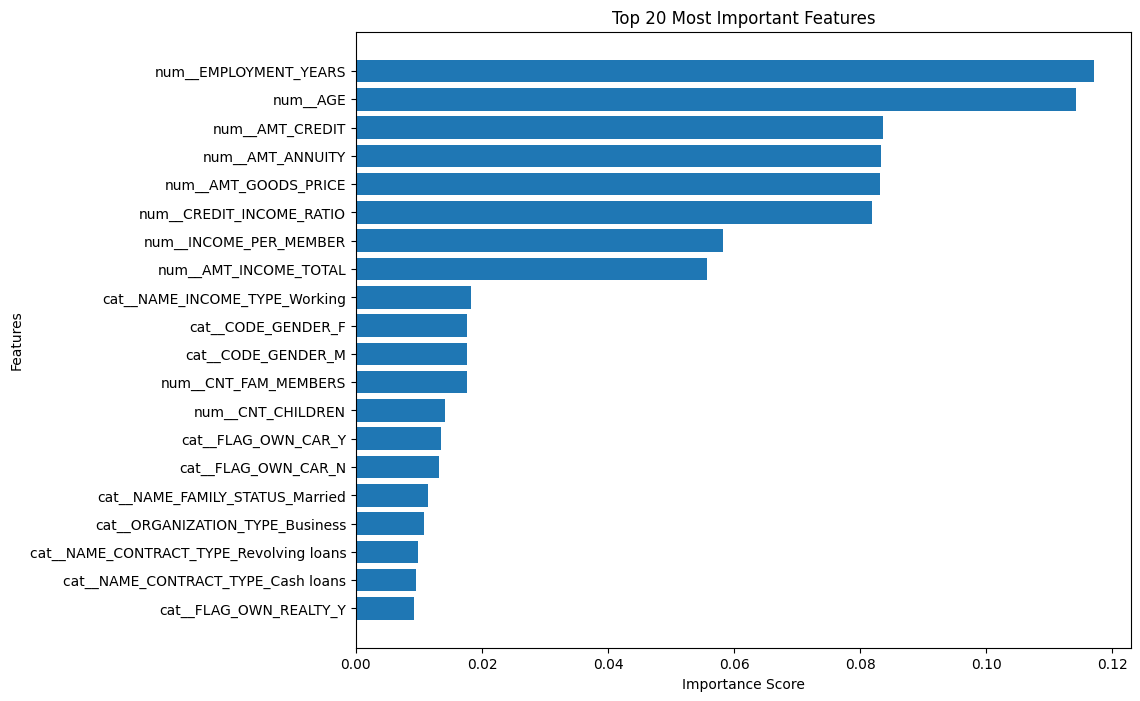

In [106]:
import pandas as pd
import matplotlib.pyplot as plt

# =====================================
# GET FEATURE NAMES AFTER PREPROCESSING
# =====================================

feature_names = (
    pipeline_rf_v2.named_steps[
        "preprocessing"
    ]
    .get_feature_names_out()
)

# =====================================
# FEATURE IMPORTANCE
# =====================================

importance = (
    pipeline_rf_v2.named_steps[
        "model"
    ]
    .feature_importances_
)

feature_importance_df = pd.DataFrame({

    "Feature":
    feature_names,

    "Importance":
    importance

})

feature_importance_df = (
    feature_importance_df
    .sort_values(
        by="Importance",
        ascending=False
    )
)

# =====================================
# TOP FEATURES
# =====================================

print(
    feature_importance_df
    .head(20)
)

# =====================================
# PLOT
# =====================================

plt.figure(figsize=(10,8))

plt.barh(
    feature_importance_df[
        "Feature"
    ].head(20)[::-1],

    feature_importance_df[
        "Importance"
    ].head(20)[::-1]
)

plt.xlabel(
    "Importance Score"
)

plt.ylabel(
    "Features"
)

plt.title(
    "Top 20 Most Important Features"
)

plt.show()

In [146]:
home_credit_df_3[home_credit_df_3["TARGET"]==1].head(20)

,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_INCOME_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,OCCUPATION_TYPE,CNT_FAM_MEMBERS,ORGANIZATION_TYPE
0,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Working,Single / not married,House / apartment,-9461,-637,Laborers,1.0,Business Entity Type 3
26,1,Cash loans,F,N,Y,0,112500.0,979992.0,27076.5,702000.0,Working,Widow,House / apartment,-18724,-2628,Cooking staff,1.0,Business Entity Type 3
40,1,Cash loans,M,N,Y,0,202500.0,1193580.0,35028.0,855000.0,Commercial associate,Married,House / apartment,-17482,-1262,Laborers,2.0,Business Entity Type 3
42,1,Cash loans,F,N,N,0,135000.0,288873.0,16258.5,238500.0,Working,Civil marriage,House / apartment,-13384,-3597,Sales staff,2.0,Self-employed
81,1,Cash loans,F,N,Y,0,81000.0,252000.0,14593.5,252000.0,Pensioner,Married,House / apartment,-24794,365243,NaN,2.0,XNA
94,1,Cash loans,M,Y,Y,0,315000.0,953460.0,64107.0,900000.0,Commercial associate,Single / not married,With parents,-10199,-2015,NaN,1.0,Industry: type 4
110,1,Cash loans,F,N,Y,1,157500.0,723996.0,30802.5,585000.0,Commercial associate,Separated,House / apartment,-10526,-267,Sales staff,2.0,Trade: type 2
138,1,Cash loans,M,N,Y,0,292500.0,675000.0,36747.0,675000.0,Working,Married,House / apartment,-16667,-200,Managers,2.0,Business Entity Type 3
154,1,Cash loans,F,N,Y,0,157500.0,245619.0,12667.5,166500.0,Working,Single / not married,House / apartment,-17538,-7676,Private service staff,1.0,Business Entity Type 3
163,1,Cash loans,F,N,N,0,111915.0,225000.0,21037.5,225000.0,Commercial associate,Single / not married,With parents,-7989,-150,Core staff,1.0,Trade: type 3
